# Sprint 3 — 10_evaluation.ipynb
## Rol: Metrics Evaluator

### Objetivo
Evaluar los modelos baseline entrenados en `09_baseline_models.ipynb` usando métricas de clasificación y validación cruzada estratificada de 5 folds, generando artefactos reproducibles para el siguiente rol (`11_model_comparison.ipynb`).

### Qué sí hace este notebook
- Carga los pipelines baseline ya entrenados.
- Ejecuta **Stratified 5-Fold Cross-Validation**.
- Calcula métricas principales:
  - Accuracy
  - Precision
  - Recall
  - F1
  - AUC-ROC
- Genera métricas por fold y un resumen consolidado.
- Produce métricas OOF (out-of-fold) para evitar tocar el test final.
- Genera:
  - classification report
  - confusion matrices
  - curvas ROC
  - curvas Precision-Recall
- Exporta outputs limpios para el siguiente rol.

### Qué NO hace este notebook
- No tunea hiperparámetros.
- No selecciona el ganador final.
- No toca el test set final para evaluación definitiva.
- No reentrena modelos nuevos; evalúa los ya persistidos.

### Inputs esperados
- `data/processed/train_balanced.csv`
- `data/processed/test_original.csv` *(solo documentado como insumo disponible; no usar para evaluación definitiva aquí)*
- `models/baseline_manifest.csv`
- `models/baseline_smoke_test.csv`
- `models/baseline_lr.pkl`
- `models/baseline_dt.pkl`
- `models/baseline_rf.pkl`
- `models/baseline_svm.pkl`
- `models/baseline_knn.pkl`

### Outputs esperados
- `models/evaluation_cv_summary.csv`
- `models/evaluation_cv_fold_results.csv`
- `models/evaluation_oof_metrics.csv`
- `models/evaluation_classification_reports.csv`
- `reports/figures/sprint3/roc_baselines.png`
- `reports/figures/sprint3/pr_baselines.png`
- `reports/figures/sprint3/confusion_matrices_baselines.png`

> Nota: si alguno de estos artefactos crece demasiado o el equipo decide versionar outputs derivados con DVC, se puede aplicar `dvc add` a esos archivos. Por defecto, los CSV/PNG de esta etapa deberían ser suficientemente livianos para Git.

## 1. Checklist antes de correr
Antes de ejecutar este notebook, valida:
1. Estar en el entorno correcto del proyecto.
2. Tener presentes los `.pkl` del rol anterior.
3. Haber hecho `dvc pull` si esos `.pkl` están versionados con DVC.
4. Confirmar el target y la métrica principal del negocio.

> Recomendación: usa **OOF predictions** sobre `train_balanced.csv` para reportes, matrices y curvas. Así no consumes el test set final en Sprint 3.

In [12]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    precision_recall_curve,
)

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

## 2. Configuración del proyecto
Ajusta solo si tu estructura cambió.

In [4]:
PROJECT_ROOT = Path(".").resolve().parent if Path.cwd().name == "notebooks" else Path(".").resolve()
import sys
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
REPORTS_DIR = PROJECT_ROOT / "reports" / "figures" / "sprint3"

TRAIN_PATH = DATA_DIR / "train_balanced.csv"
TEST_PATH = DATA_DIR / "test_original.csv"

BASELINE_MANIFEST_PATH = MODELS_DIR / "baseline_manifest.csv"
BASELINE_SMOKE_PATH = MODELS_DIR / "baseline_smoke_test.csv"

TARGET_COL = "IsBadBuy"
PRIMARY_METRIC = "f1"  # ajustar solo si el equipo definió otra métrica principal
RANDOM_STATE = 42
N_SPLITS = 5

REPORTS_DIR.mkdir(parents=True, exist_ok=True)

In [5]:
expected_files = [
    TRAIN_PATH,
    BASELINE_MANIFEST_PATH,
    BASELINE_SMOKE_PATH,
    MODELS_DIR / "baseline_lr.pkl",
    MODELS_DIR / "baseline_dt.pkl",
    MODELS_DIR / "baseline_rf.pkl",
    MODELS_DIR / "baseline_svm.pkl",
    MODELS_DIR / "baseline_knn.pkl",
]

for path in expected_files:
    print(path, "->", path.exists())

if not all(path.exists() for path in expected_files):
    missing = [str(path) for path in expected_files if not path.exists()]
    raise FileNotFoundError(f"Faltan insumos requeridos: {missing}")

# Validar carga de un modelo mínimo para asegurar sys.path
import joblib
try:
    _test_load = joblib.load(MODELS_DIR / 'baseline_lr.pkl')
    print('Carga de prueba (baseline_lr.pkl) exitosa.')
except Exception as e:
    raise RuntimeError(f'Error al cargar el modelo de prueba: {e}')


/Users/alexandralozano/dp261-g1/data/processed/train_balanced.csv -> True
/Users/alexandralozano/dp261-g1/models/baseline_manifest.csv -> True
/Users/alexandralozano/dp261-g1/models/baseline_smoke_test.csv -> True
/Users/alexandralozano/dp261-g1/models/baseline_lr.pkl -> True
/Users/alexandralozano/dp261-g1/models/baseline_dt.pkl -> True
/Users/alexandralozano/dp261-g1/models/baseline_rf.pkl -> True
/Users/alexandralozano/dp261-g1/models/baseline_svm.pkl -> True
/Users/alexandralozano/dp261-g1/models/baseline_knn.pkl -> True
Carga de prueba (baseline_lr.pkl) exitosa.


## 3. Carga de datos e insumos del rol anterior

In [6]:
train_df = pd.read_csv(TRAIN_PATH)
baseline_manifest = pd.read_csv(BASELINE_MANIFEST_PATH)
baseline_smoke = pd.read_csv(BASELINE_SMOKE_PATH)

print("train_df shape:", train_df.shape)
display(baseline_manifest)
display(baseline_smoke)

train_df shape: (102410, 60)


,model_key,estimator,artifact_path,target_col,train_rows,train_columns,status,notes
0,lr,LogisticRegression,/Users/alexandralozano/dp261-g1/models/baselin...,IsBadBuy,102410,59,trained,Default baseline parameters
1,dt,DecisionTreeClassifier,/Users/alexandralozano/dp261-g1/models/baselin...,IsBadBuy,102410,59,trained,Default baseline parameters
2,rf,RandomForestClassifier,/Users/alexandralozano/dp261-g1/models/baselin...,IsBadBuy,102410,59,trained,Default baseline parameters
3,svm,SVC,/Users/alexandralozano/dp261-g1/models/baselin...,IsBadBuy,102410,59,trained,Default baseline parameters
4,knn,KNeighborsClassifier,/Users/alexandralozano/dp261-g1/models/baselin...,IsBadBuy,102410,59,trained,Default baseline parameters


,model_key,artifact_exists,n_predictions,sample_predictions
0,lr,True,5,"[1, 1, 0, 1, 1]"
1,dt,True,5,"[1, 1, 0, 0, 1]"
2,rf,True,5,"[1, 1, 0, 0, 1]"
3,svm,True,5,"[1, 1, 1, 1, 1]"
4,knn,True,5,"[1, 1, 1, 0, 1]"


In [7]:
if TARGET_COL not in train_df.columns:
    raise KeyError(f"El target '{TARGET_COL}' no existe en train_df.")

X = train_df.drop(columns=[TARGET_COL]).copy()
y = train_df[TARGET_COL].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Target distribution:")
display(y.value_counts(dropna=False))

X shape: (102410, 59)
y shape: (102410,)
Target distribution:


IsBadBuy
1    51205
0    51205
Name: count, dtype: int64

## 4. Carga de modelos baseline
Cargamos los pipelines persistidos por el Baseline Trainer.

In [8]:
model_files = {
    "lr": MODELS_DIR / "baseline_lr.pkl",
    "dt": MODELS_DIR / "baseline_dt.pkl",
    "rf": MODELS_DIR / "baseline_rf.pkl",
    "svm": MODELS_DIR / "baseline_svm.pkl",
    "knn": MODELS_DIR / "baseline_knn.pkl",
}

models = {name: joblib.load(path) for name, path in model_files.items()}

print("Modelos cargados:")
for name, model in models.items():
    print("-", name, type(model))

Modelos cargados:
- lr <class 'sklearn.pipeline.Pipeline'>
- dt <class 'sklearn.pipeline.Pipeline'>
- rf <class 'sklearn.pipeline.Pipeline'>
- svm <class 'sklearn.pipeline.Pipeline'>
- knn <class 'sklearn.pipeline.Pipeline'>


## 5. Configuración de Cross-Validation y métricas
Se usa `StratifiedKFold` de 5 folds para mantener la proporción de clases y obtener métricas robustas.

In [9]:
cv = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
}

scoring

{'accuracy': 'accuracy',
 'precision': 'precision',
 'recall': 'recall',
 'f1': 'f1',
 'roc_auc': 'roc_auc'}

## 6. Evaluación por cross-validation
Esta sección genera dos salidas clave:
- métricas por fold (`evaluation_cv_fold_results.csv`)
- resumen consolidado (`evaluation_cv_summary.csv`)

In [18]:
# orden sugerido: rápidos primero, svm al final
model_order = ["lr", "dt", "rf", "knn", "svm"]

fold_rows = []
summary_rows = []

MODELS_DIR.mkdir(parents=True, exist_ok=True)

for name in model_order:
    pipe = models[name]
    print(f"\n=== Evaluando {name} ===")
    start = time.time()

    results = cross_validate(
        pipe,
        X,
        y,
        cv=cv,
        scoring=scoring,
        return_train_score=False,
        n_jobs=1,
        error_score="raise",
    )

    elapsed = time.time() - start
    print(f"{name} terminado en {elapsed/60:.2f} min")

    n_folds = len(results["test_accuracy"])  # debería ser 5

    for fold_idx in range(n_folds):
        fold_rows.append({
            "model_key": name,
            "fold": fold_idx + 1,
            "test_accuracy": results["test_accuracy"][fold_idx],
            "test_precision": results["test_precision"][fold_idx],
            "test_recall": results["test_recall"][fold_idx],
            "test_f1": results["test_f1"][fold_idx],
            "test_roc_auc": results["test_roc_auc"][fold_idx],
            "fit_time": results["fit_time"][fold_idx],
            "score_time": results["score_time"][fold_idx],
        })

    summary_rows.append({
        "model_key": name,
        "primary_metric": PRIMARY_METRIC,
        "cv_folds": n_folds,
        "test_accuracy_mean": np.mean(results["test_accuracy"]),
        "test_accuracy_std": np.std(results["test_accuracy"]),
        "test_precision_mean": np.mean(results["test_precision"]),
        "test_precision_std": np.std(results["test_precision"]),
        "test_recall_mean": np.mean(results["test_recall"]),
        "test_recall_std": np.std(results["test_recall"]),
        "test_f1_mean": np.mean(results["test_f1"]),
        "test_f1_std": np.std(results["test_f1"]),
        "test_roc_auc_mean": np.mean(results["test_roc_auc"]),
        "test_roc_auc_std": np.std(results["test_roc_auc"]),
        "fit_time_mean": np.mean(results["fit_time"]),
        "score_time_mean": np.mean(results["score_time"]),
    })

    # guardado parcial por seguridad
    cv_fold_df_partial = pd.DataFrame(fold_rows)
    cv_summary_df_partial = pd.DataFrame(summary_rows).sort_values(
        by=f"test_{PRIMARY_METRIC}_mean",
        ascending=False,
    )

    cv_fold_df_partial.to_csv(MODELS_DIR / "evaluation_cv_fold_results_partial.csv", index=False)
    cv_summary_df_partial.to_csv(MODELS_DIR / "evaluation_cv_summary_partial.csv", index=False)

cv_fold_df = pd.DataFrame(fold_rows)
cv_summary_df = pd.DataFrame(summary_rows).sort_values(
    by=f"test_{PRIMARY_METRIC}_mean",
    ascending=False,
)

display(cv_summary_df)
display(cv_fold_df.head())


=== Evaluando lr ===
lr terminado en 0.87 min

=== Evaluando dt ===
dt terminado en 0.99 min

=== Evaluando rf ===
rf terminado en 5.35 min

=== Evaluando knn ===
knn terminado en 19.65 min

=== Evaluando svm ===
svm terminado en 2.11 min


,model_key,primary_metric,cv_folds,test_accuracy_mean,test_accuracy_std,test_precision_mean,test_precision_std,test_recall_mean,test_recall_std,test_f1_mean,test_f1_std,test_roc_auc_mean,test_roc_auc_std,fit_time_mean,score_time_mean
2,rf,f1,5,0.988653,0.000424,0.979625,0.000929,0.998067,0.000272,0.988759,0.000414,0.999437,0.000143,63.006968,1.162740
1,dt,f1,5,0.925134,0.001772,0.870759,0.002643,0.998477,0.000132,0.930252,0.001539,0.925134,0.001772,11.453154,0.365945
3,knn,f1,5,0.825144,0.001038,0.754863,0.001089,0.963031,0.002372,0.846332,0.000978,0.907716,0.000912,1.322752,234.480872
4,svm,f1,5,0.499502,0.000377,0.499749,0.000191,0.994122,0.003770,0.665131,0.001001,0.560083,0.060726,18.243641,7.023308
0,lr,f1,5,0.663441,0.002604,0.665506,0.003741,0.657319,0.007572,0.661351,0.003501,0.724553,0.002235,10.076349,0.384313


,model_key,fold,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc,fit_time,score_time
0,lr,1,0.664925,0.665848,0.662142,0.663990,0.725390,9.960488,0.482897
1,lr,2,0.665804,0.665659,0.666244,0.665951,0.727354,9.917371,0.340393
2,lr,3,0.662679,0.663333,0.660678,0.662003,0.725481,10.171457,0.309904
3,lr,4,0.658676,0.660700,0.652378,0.656513,0.720667,10.568763,0.312283
4,lr,5,0.665121,0.671989,0.645152,0.658297,0.723874,9.763668,0.476087


In [19]:
subset_models = ["lr", "dt", "rf",'svm']

overfit_rows = []

for name in subset_models:
    pipe = models[name]
    print(f"\n=== Over/underfitting check: {name} ===")
    start = time.time()

    results = cross_validate(
        pipe,
        X,
        y,
        cv=cv,
        scoring=scoring,
        return_train_score=True,
        n_jobs=1,
        error_score="raise",
    )

    elapsed = time.time() - start
    print(f"{name} terminado en {elapsed/60:.2f} min")

    overfit_rows.append({
        "model_key": name,
        "train_accuracy_mean": np.mean(results["train_accuracy"]),
        "test_accuracy_mean": np.mean(results["test_accuracy"]),
        "accuracy_gap": np.mean(results["train_accuracy"]) - np.mean(results["test_accuracy"]),

        "train_precision_mean": np.mean(results["train_precision"]),
        "test_precision_mean": np.mean(results["test_precision"]),
        "precision_gap": np.mean(results["train_precision"]) - np.mean(results["test_precision"]),

        "train_recall_mean": np.mean(results["train_recall"]),
        "test_recall_mean": np.mean(results["test_recall"]),
        "recall_gap": np.mean(results["train_recall"]) - np.mean(results["test_recall"]),

        "train_f1_mean": np.mean(results["train_f1"]),
        "test_f1_mean": np.mean(results["test_f1"]),
        "f1_gap": np.mean(results["train_f1"]) - np.mean(results["test_f1"]),

        "train_roc_auc_mean": np.mean(results["train_roc_auc"]),
        "test_roc_auc_mean": np.mean(results["test_roc_auc"]),
        "roc_auc_gap": np.mean(results["train_roc_auc"]) - np.mean(results["test_roc_auc"]),
    })

overfit_summary_df = pd.DataFrame(overfit_rows)

def diagnose_gap(gap):
    if gap >= 0.10:
        return "posible overfitting"
    elif gap <= 0.03:
        return "sin brecha fuerte"
    else:
        return "brecha moderada"

overfit_summary_df["f1_diagnosis"] = overfit_summary_df["f1_gap"].apply(diagnose_gap)

display(overfit_summary_df)

overfit_summary_df.to_csv(MODELS_DIR / "evaluation_train_test_gap_subset.csv", index=False)


=== Over/underfitting check: lr ===
lr terminado en 0.93 min

=== Over/underfitting check: dt ===
dt terminado en 1.07 min

=== Over/underfitting check: rf ===
rf terminado en 5.74 min

=== Over/underfitting check: svm ===
svm terminado en 4.49 min


,model_key,train_accuracy_mean,test_accuracy_mean,accuracy_gap,train_precision_mean,test_precision_mean,precision_gap,train_recall_mean,test_recall_mean,recall_gap,train_f1_mean,test_f1_mean,f1_gap,train_roc_auc_mean,test_roc_auc_mean,roc_auc_gap,f1_diagnosis
0,lr,0.665702,0.663441,0.002261,0.667737,0.665506,0.002231,0.659701,0.657319,0.002383,0.663678,0.661351,0.002328,0.727596,0.724553,0.003043,sin brecha fuerte
1,dt,1.000000,0.925134,0.074866,1.000000,0.870759,0.129241,1.000000,0.998477,0.001523,1.000000,0.930252,0.069748,1.000000,0.925134,0.074866,brecha moderada
2,rf,1.000000,0.988653,0.011347,1.000000,0.979625,0.020375,1.000000,0.998067,0.001933,1.000000,0.988759,0.011241,1.000000,0.999437,0.000563,sin brecha fuerte
3,svm,0.499526,0.499502,0.000024,0.499761,0.499749,0.000012,0.994210,0.994122,0.000088,0.665161,0.665131,0.000030,0.565363,0.560083,0.005281,sin brecha fuerte


## 7. Predicciones OOF para reportes, matrices y curvas
Para evitar usar el test set final en Sprint 3, generamos:
- `y_pred_oof`
- `y_score_oof`

Según el modelo:
- si existe `predict_proba`, usamos la probabilidad de la clase positiva;
- si no, usamos `decision_function`;
- si ninguna existe, caeremos en `predict` como último recurso.

In [22]:
def get_oof_scores(estimator, X, y, cv):
    if hasattr(estimator, "predict_proba"):
        method = "predict_proba"
        scores = cross_val_predict(
            estimator, X, y, cv=cv, method=method, n_jobs=1
        )[:, 1]
    elif hasattr(estimator, "decision_function"):
        method = "decision_function"
        scores = cross_val_predict(
            estimator, X, y, cv=cv, method=method, n_jobs=1
        )
    else:
        method = "predict"
        scores = cross_val_predict(
            estimator, X, y, cv=cv, method=method, n_jobs=1
        )
    return method, scores

model_order = ["lr", "dt", "rf", "knn", "svm"]

oof_metrics_rows = []
class_report_rows = {}
confusion_matrices = {}
roc_data = {}
pr_data = {}

for name in model_order:
    pipe = models[name]
    print(f"\n=== OOF: {name} ===")
    start = time.time()

    y_pred_oof = cross_val_predict(
        pipe, X, y, cv=cv, method="predict", n_jobs=1
    )

    score_method, y_score_oof = get_oof_scores(pipe, X, y, cv)

    elapsed = time.time() - start
    print(f"{name} OOF terminado en {elapsed/60:.2f} min")

    model_metrics = {
        "model_key": name,
        "score_method": score_method,
        "oof_accuracy": accuracy_score(y, y_pred_oof),
        "oof_precision": precision_score(y, y_pred_oof, zero_division=0),
        "oof_recall": recall_score(y, y_pred_oof, zero_division=0),
        "oof_f1": f1_score(y, y_pred_oof, zero_division=0),
    }

    try:
        model_metrics["oof_roc_auc"] = roc_auc_score(y, y_score_oof)
    except Exception:
        model_metrics["oof_roc_auc"] = np.nan

    try:
        model_metrics["oof_average_precision"] = average_precision_score(y, y_score_oof)
    except Exception:
        model_metrics["oof_average_precision"] = np.nan

    oof_metrics_rows.append(model_metrics)

    report_dict = classification_report(
        y, y_pred_oof, output_dict=True, zero_division=0
    )
    report_df = pd.DataFrame(report_dict).T.reset_index().rename(columns={"index": "label"})
    report_df.insert(0, "model_key", name)
    class_report_rows[name] = report_df

    confusion_matrices[name] = confusion_matrix(y, y_pred_oof)

    try:
        fpr, tpr, _ = roc_curve(y, y_score_oof)
        roc_data[name] = (fpr, tpr)
    except Exception:
        roc_data[name] = None

    try:
        precision, recall, _ = precision_recall_curve(y, y_score_oof)
        pr_data[name] = (precision, recall)
    except Exception:
        pr_data[name] = None

    # guardado parcial
    pd.DataFrame(oof_metrics_rows).to_csv(
        MODELS_DIR / "evaluation_oof_metrics_partial.csv",
        index=False
    )

classification_reports_df = pd.concat(class_report_rows.values(), ignore_index=True)
oof_metrics_df = pd.DataFrame(oof_metrics_rows).sort_values(
    by="oof_f1", ascending=False
)

display(oof_metrics_df)
display(classification_reports_df.head(20))


=== OOF: lr ===
lr OOF terminado en 1.64 min

=== OOF: dt ===
dt OOF terminado en 2.04 min

=== OOF: rf ===
rf OOF terminado en 10.99 min

=== OOF: knn ===
knn OOF terminado en 20.87 min

=== OOF: svm ===
svm OOF terminado en 3.62 min


,model_key,score_method,oof_accuracy,oof_precision,oof_recall,oof_f1,oof_roc_auc,oof_average_precision
2,rf,predict_proba,0.988653,0.979624,0.998067,0.988759,0.999437,0.999592
1,dt,predict_proba,0.925134,0.870751,0.998477,0.930250,0.925134,0.870186
3,knn,predict_proba,0.825144,0.754860,0.963031,0.846333,0.907709,0.855978
4,svm,decision_function,0.499502,0.499750,0.994122,0.665134,0.511980,0.520305
0,lr,predict_proba,0.663441,0.665467,0.657319,0.661368,0.724474,0.708676


,model_key,label,precision,recall,f1-score,support
0,lr,0,0.661464,0.669564,0.665489,51205.000000
1,lr,1,0.665467,0.657319,0.661368,51205.000000
2,lr,accuracy,0.663441,0.663441,0.663441,0.663441
3,lr,macro avg,0.663466,0.663441,0.663428,102410.000000
4,lr,weighted avg,0.663466,0.663441,0.663428,102410.000000
5,dt,0,0.998215,0.851792,0.919209,51205.000000
6,dt,1,0.870751,0.998477,0.930250,51205.000000
7,dt,accuracy,0.925134,0.925134,0.925134,0.925134
8,dt,macro avg,0.934483,0.925134,0.924729,102410.000000
9,dt,weighted avg,0.934483,0.925134,0.924729,102410.000000


## 8. Visualizaciones
Las curvas y matrices se generan a partir de predicciones OOF, no del test final.

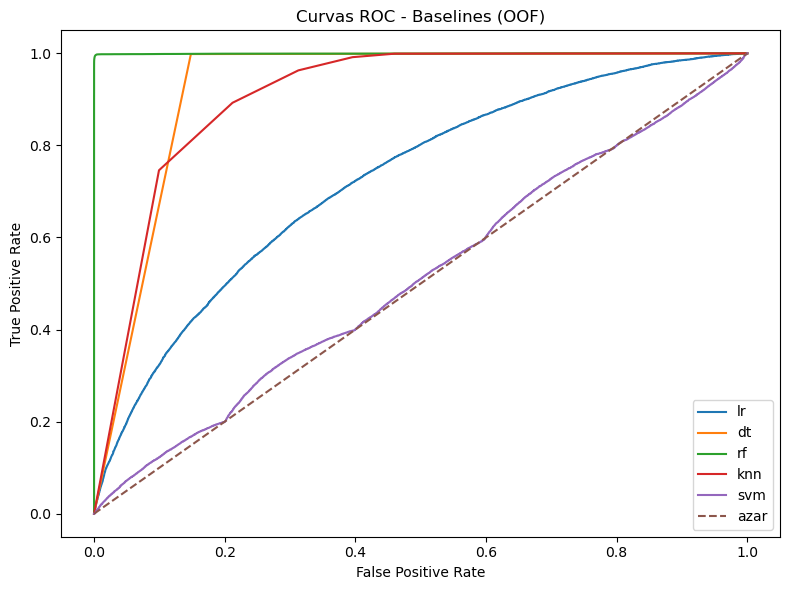

Saved: /Users/alexandralozano/dp261-g1/reports/figures/sprint3/roc_baselines.png


In [23]:
# ROC curves
fig, ax = plt.subplots(figsize=(8, 6))
for name, data in roc_data.items():
    if data is not None:
        fpr, tpr = data
        ax.plot(fpr, tpr, label=name)
ax.plot([0, 1], [0, 1], "--", label="azar")
ax.set_title("Curvas ROC - Baselines (OOF)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right")
plt.tight_layout()

roc_path = REPORTS_DIR / "roc_baselines.png"
plt.savefig(roc_path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", roc_path)

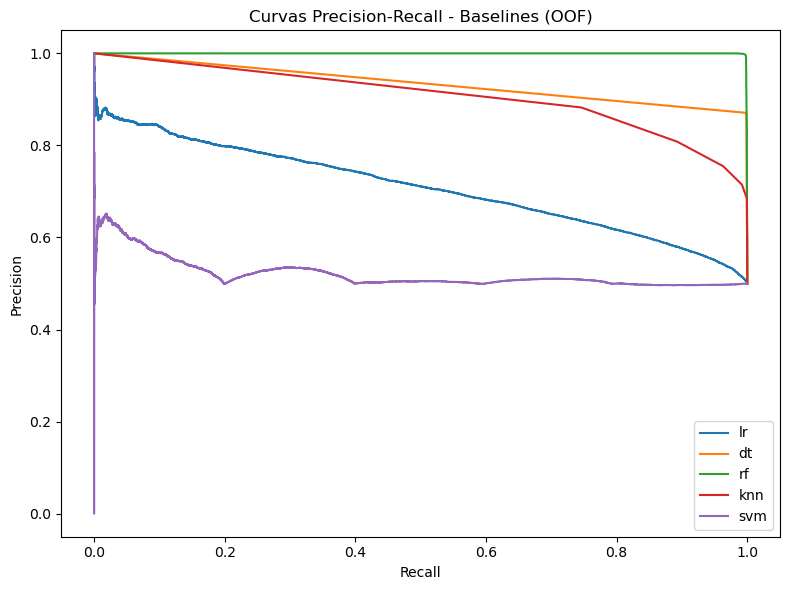

Saved: /Users/alexandralozano/dp261-g1/reports/figures/sprint3/pr_baselines.png


In [24]:
# Precision-Recall curves
fig, ax = plt.subplots(figsize=(8, 6))
for name, data in pr_data.items():
    if data is not None:
        precision, recall = data
        ax.plot(recall, precision, label=name)
ax.set_title("Curvas Precision-Recall - Baselines (OOF)")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend(loc="best")
plt.tight_layout()

pr_path = REPORTS_DIR / "pr_baselines.png"
plt.savefig(pr_path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", pr_path)

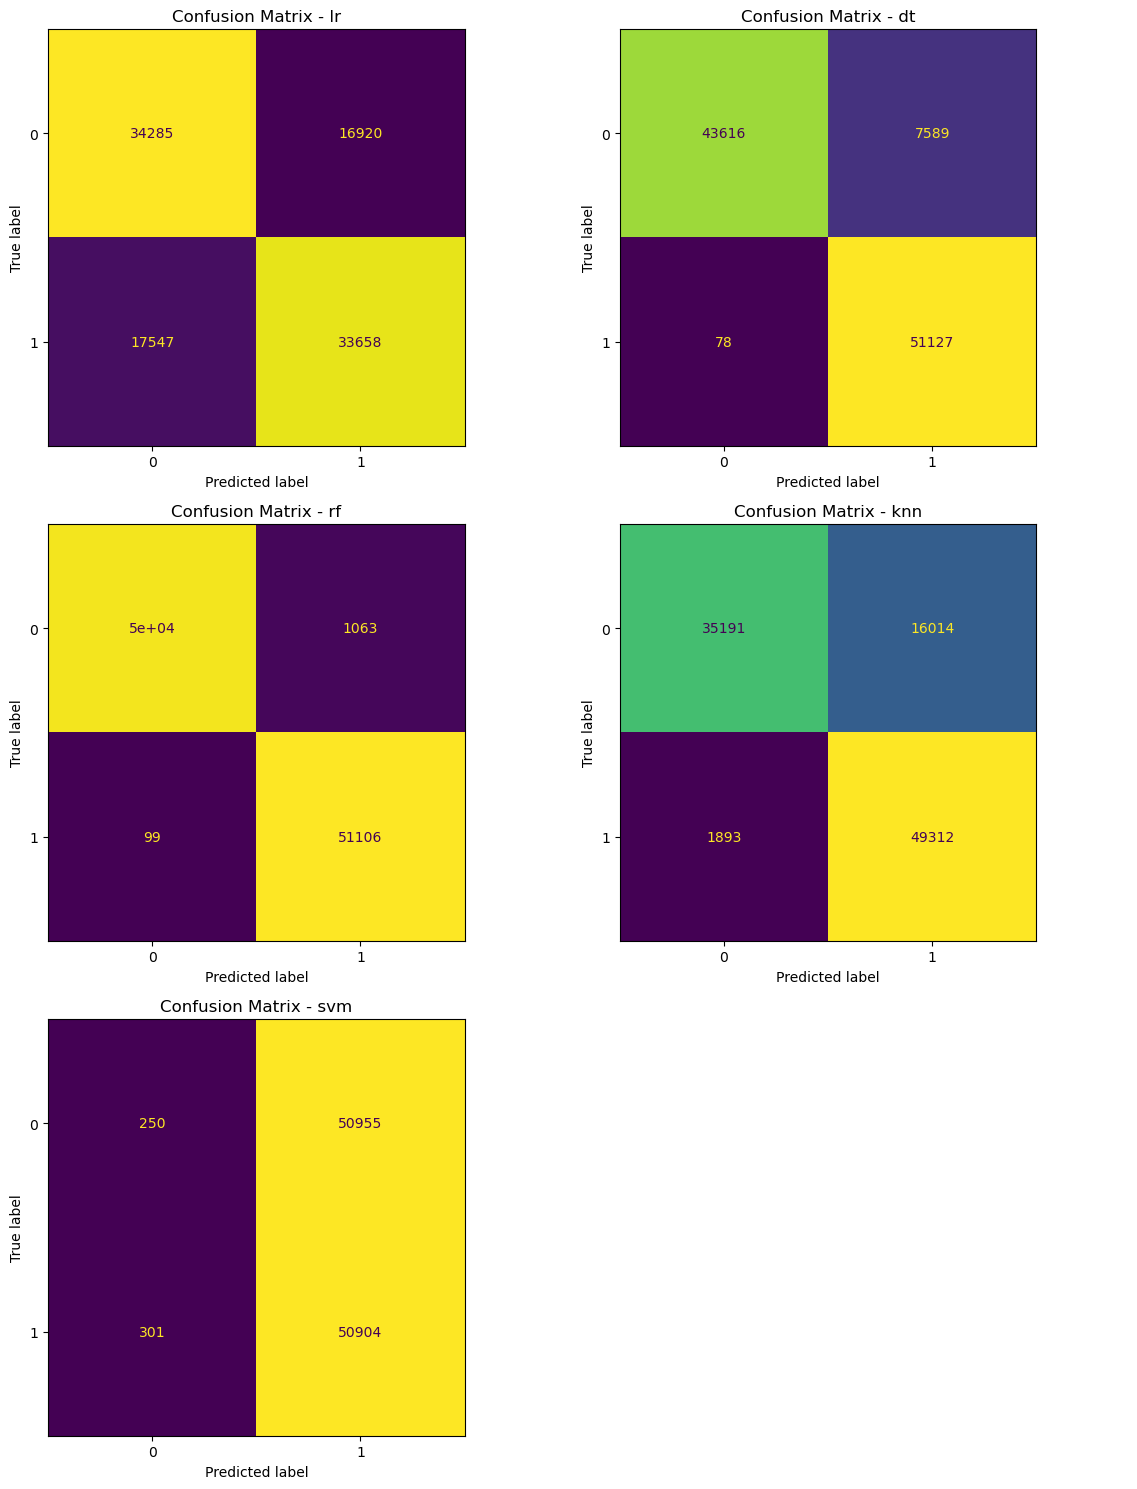

Saved: /Users/alexandralozano/dp261-g1/reports/figures/sprint3/confusion_matrices_baselines.png


In [25]:
# Confusion matrices
model_names = list(confusion_matrices.keys())
n_models = len(model_names)
ncols = 2
nrows = int(np.ceil(n_models / ncols))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12, 5 * nrows))
axes = np.array(axes).reshape(-1)

for ax, name in zip(axes, model_names):
    cm = confusion_matrices[name]
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(f"Confusion Matrix - {name}")

for ax in axes[len(model_names):]:
    ax.axis("off")

plt.tight_layout()
cm_path = REPORTS_DIR / "confusion_matrices_baselines.png"
plt.savefig(cm_path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", cm_path)

## 9. Persistencia de outputs
Estos CSV son los insumos directos del siguiente rol (`Model Comparator`).

In [26]:
cv_summary_path = MODELS_DIR / "evaluation_cv_summary.csv"
cv_fold_path = MODELS_DIR / "evaluation_cv_fold_results.csv"
oof_metrics_path = MODELS_DIR / "evaluation_oof_metrics.csv"
class_reports_path = MODELS_DIR / "evaluation_classification_reports.csv"

cv_summary_df.to_csv(cv_summary_path, index=False)
cv_fold_df.to_csv(cv_fold_path, index=False)
oof_metrics_df.to_csv(oof_metrics_path, index=False)
classification_reports_df.to_csv(class_reports_path, index=False)

print("Saved:", cv_summary_path)
print("Saved:", cv_fold_path)
print("Saved:", oof_metrics_path)
print("Saved:", class_reports_path)

Saved: /Users/alexandralozano/dp261-g1/models/evaluation_cv_summary.csv
Saved: /Users/alexandralozano/dp261-g1/models/evaluation_cv_fold_results.csv
Saved: /Users/alexandralozano/dp261-g1/models/evaluation_oof_metrics.csv
Saved: /Users/alexandralozano/dp261-g1/models/evaluation_classification_reports.csv


## 10. Revisión de artefactos generados

In [27]:
generated_paths = [
    cv_summary_path,
    cv_fold_path,
    oof_metrics_path,
    class_reports_path,
    roc_path,
    pr_path,
    cm_path,
]

artifact_rows = []
for path in generated_paths:
    artifact_rows.append({
        "artifact_path": str(path),
        "exists": path.exists(),
        "size_kb": round(path.stat().st_size / 1024, 2) if path.exists() else None,
    })

generated_df = pd.DataFrame(artifact_rows)
display(generated_df)

,artifact_path,exists,size_kb
0,/Users/alexandralozano/dp261-g1/models/evaluat...,True,1.45
1,/Users/alexandralozano/dp261-g1/models/evaluat...,True,3.42
2,/Users/alexandralozano/dp261-g1/models/evaluat...,True,0.74
3,/Users/alexandralozano/dp261-g1/models/evaluat...,True,1.96
4,/Users/alexandralozano/dp261-g1/reports/figure...,True,90.67
5,/Users/alexandralozano/dp261-g1/reports/figure...,True,58.33
6,/Users/alexandralozano/dp261-g1/reports/figure...,True,82.92


## 11. Handoff al siguiente rol
### Lo que ya queda listo
- resumen CV por modelo
- detalle por fold
- métricas OOF
- classification reports
- curvas ROC / PR
- confusion matrices

### Lo que debe hacer el siguiente rol (`11_model_comparison.ipynb`)
- consolidar resultados
- rankear modelos por la métrica principal
- analizar trade-offs
- seleccionar top 2–3 candidatos para Sprint 4
- documentar descarte de modelos

### Notas de versionado
- Si los CSV/PNG son pequeños, pueden versionarse normalmente con Git.
- Si algún output resulta demasiado grande o el equipo quiere trazabilidad total de artefactos derivados, aplicar `dvc add` a esos outputs y versionar solo los `.dvc`.
- Nunca hacer `git add` de modelos `.pkl` pesados si ya están bajo DVC.